# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pickle

# Loading Dataset

In [2]:
df = pd.read_csv("../dataset/dataset.csv")
df.head()

,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000


# Exploration and Interpretation of Dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Property_ID    300 non-null    str  
 1   Area           300 non-null    int64
 2   Bedrooms       300 non-null    int64
 3   Bathrooms      300 non-null    int64
 4   Age            300 non-null    int64
 5   Location       300 non-null    str  
 6   Property_Type  300 non-null    str  
 7   Price          300 non-null    int64
dtypes: int64(5), str(3)
memory usage: 18.9 KB


In [11]:
location_unique_values = df['Location'].unique()
print(location_unique_values)
location_unique_values_counts = df['Location'].value_counts()
print(location_unique_values_counts)

<StringArray>
['Rural', 'Suburb', 'City Center']
Length: 3, dtype: str
Location
Suburb         105
Rural           98
City Center     97
Name: count, dtype: int64


In [12]:
property_type_unique_values = df['Property_Type'].unique()
print(property_type_unique_values)
property_type_unique_values_counts = df['Property_Type'].value_counts()
print(property_type_unique_values_counts)

<StringArray>
['House', 'Villa', 'Apartment']
Length: 3, dtype: str
Property_Type
House        107
Villa        102
Apartment     91
Name: count, dtype: int64


In [4]:
df.describe()

,Area,Bedrooms,Bathrooms,Age,Price
count,300.00000,300.000000,300.000000,300.000000,3.000000e+02
mean,2759.70000,3.033333,2.026667,25.000000,2.488366e+07
std,1297.68143,1.467219,0.792495,14.332646,1.266525e+07
min,520.00000,1.000000,1.000000,0.000000,3.695000e+06
25%,1675.75000,2.000000,1.000000,12.000000,1.527750e+07
50%,2738.00000,3.000000,2.000000,25.500000,2.236500e+07
75%,3801.25000,4.000000,3.000000,36.250000,3.460812e+07
max,4999.00000,5.000000,3.000000,49.000000,5.870000e+07


In [5]:
df.isnull().sum()

Property_ID      0
Area             0
Bedrooms         0
Bathrooms        0
Age              0
Location         0
Property_Type    0
Price            0
dtype: int64

# Target Distribution

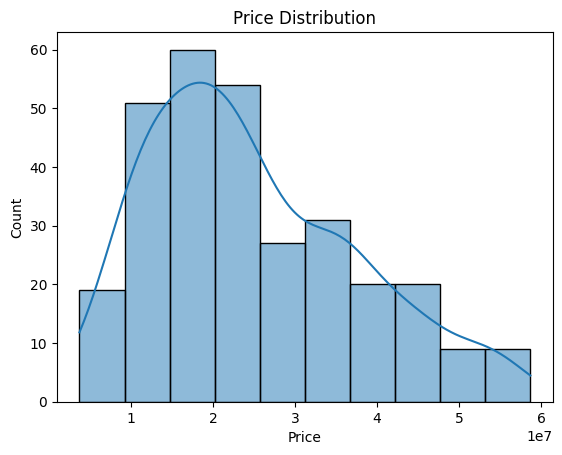

In [ ]:
sns.histplot(df["Price"], kde=True) # Kernel Density Curve for smooth line
plt.title("Price Distribution")
plt.show()

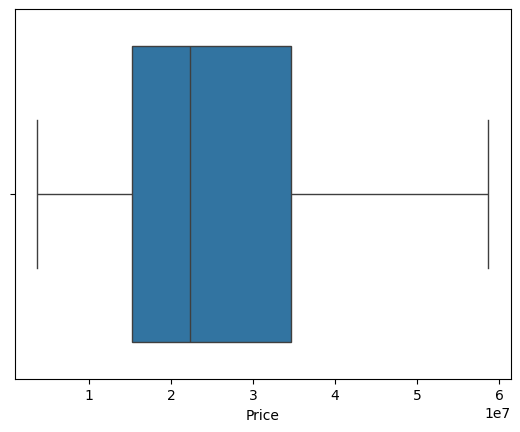

In [14]:
sns.boxplot(x=df["Price"])
plt.show()

# Train and Test Split

In [16]:
X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preprocessing Pipeline

In [ ]:
numeric_features = ["Area", "Bedrooms", "Bathrooms", "Age"]
categorical_features = ["Location", "Property_Type"]

# StandardScaler() transforms numeric data so that:
# Mean = 0
# Standard deviation = 1
numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

# OneHotEncoder() converts categories into binary columns
categorical_transformer = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combining everything with ColumnTransformer()
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# Training Models (Just trying multiple models for comparison)

In [18]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

# Comprehensive Model Evaluation

In [19]:

results = {}

for name, model in models.items():
    
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    preds = pipeline.predict(X_test)
    
    # Metrics
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    mape = np.mean(np.abs((y_test - preds) / y_test)) * 100
    
    # Cross-validation
    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="r2"
    )
    
    results[name] = {
        "pipeline": pipeline,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape,
        "CV_R2_MEAN": cv_scores.mean(),
        "CV_R2_STD": cv_scores.std()
    }
    
    print(f"===== {name} =====")
    print(f"MAE: {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"R2: {r2:.3f}")
    print(f"CV R2: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    print()

===== LinearRegression =====
MAE: 2,188,736.34
RMSE: 2,907,633.21
MAPE: 13.16%
R2: 0.941
CV R2: 0.950 ± 0.011

===== RandomForest =====
MAE: 1,436,717.50
RMSE: 1,930,869.99
MAPE: 6.76%
R2: 0.974
CV R2: 0.970 ± 0.008

===== GradientBoosting =====
MAE: 1,008,585.93
RMSE: 1,475,071.46
MAPE: 4.75%
R2: 0.985
CV R2: 0.989 ± 0.002



# Selection of the Best Model

In [20]:
best_name = max(results, key=lambda x: results[x]["R2"])
best_model = results[best_name]["pipeline"]

print("Best model:", best_name)

Best model: GradientBoosting


# Residual Analysis

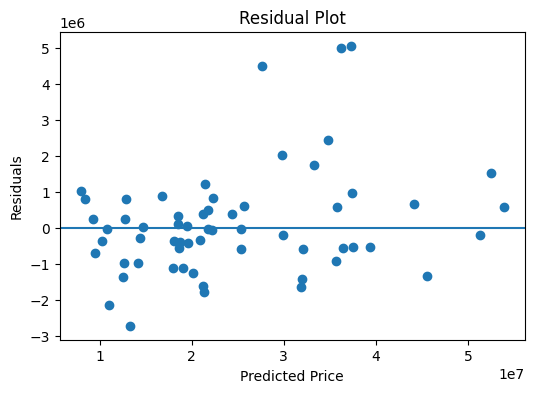

In [21]:
preds = best_model.predict(X_test)
residuals = y_test - preds

plt.figure(figsize=(6,4))
plt.scatter(preds, residuals)
plt.axhline(0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# Actual V/S Predicted Plot

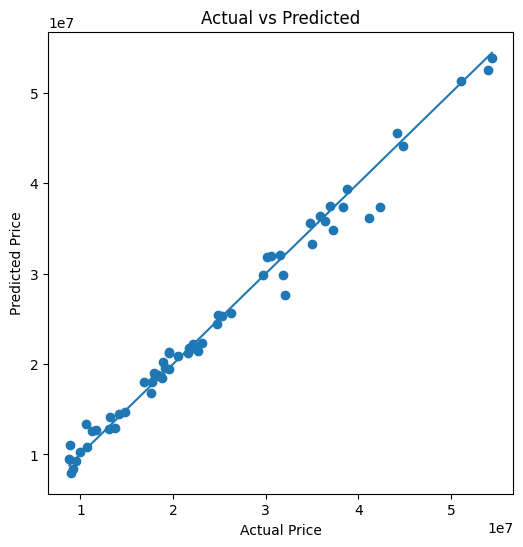

In [22]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, preds)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

# Feature Importance

In [24]:
model = best_model.named_steps["model"]

if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_
    feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
    
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False)
    
    print(importance_df)

                        Feature  Importance
0                     num__Area    0.662164
4     cat__Location_City Center    0.183772
5           cat__Location_Rural    0.088320
6          cat__Location_Suburb    0.030094
1                 num__Bedrooms    0.026142
3                      num__Age    0.008069
2                num__Bathrooms    0.001188
7  cat__Property_Type_Apartment    0.000142
8      cat__Property_Type_House    0.000102
9      cat__Property_Type_Villa    0.000007


# Save the Best Model

In [26]:

with open("house_price_model_final.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Model saved successfully")

Model saved successfully
